In [1]:
from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from skimage.morphology import binary_dilation, label
from skimage.measure import regionprops
from skimage.color import label2rgb

from sklearn.cluster import KMeans

from scipy.ndimage import distance_transform_edt

import tensorflow as tf

tf.test.gpu_device_name()

Metal device set to: 

2023-12-14 12:32:51.414386: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-14 12:32:51.414588: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


'/device:GPU:0'

Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



In [2]:
IMAGE_DIR = Path("/Users/sylvi/topo_data/hariborings/training_data/cropped/images/")

MODEL_DIR = Path(
    "/Volumes/shared/pyne_group/Shared/AFM_Data/Cas9_Minicircles/deep_learning/saved_models"
)

In [3]:
# Load the model
model = tf.keras.models.load_model(
    MODEL_DIR / f"haribonet_multiclass_2023-10-20_14-01-15_intial_results_multiclass_cropped.h5"
)
model.summary()

2023-12-14 12:32:52.991917: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-12-14 12:32:52.991941: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 512, 512, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 512, 512, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 512, 512, 16  0           ['conv2d[0][0]']                 
                                )                                                             

# Predict the mask

1/1 [==============================] - 0s 19ms/step


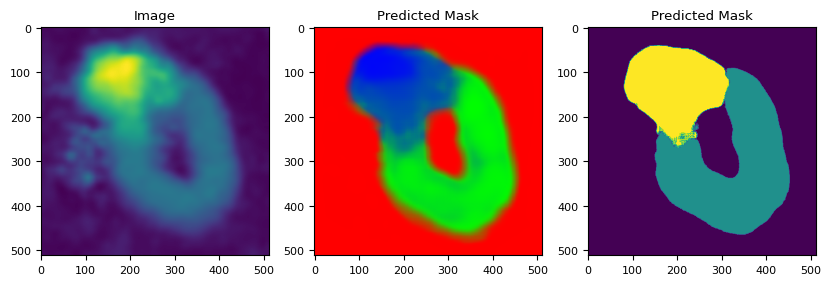

In [92]:
image_index = 6
background_threshold = 0.5
gem_threshold = 0.5
ring_threshold = 0.5


def predict_mask(
    image_index: int, gem_threshold: float, ring_threshold: float, background_threshold: float
):
    image = np.load(IMAGE_DIR / f"image_{image_index}.npy")
    image_512 = Image.fromarray(image)
    image_512 = image_512.resize((512, 512))
    image_512 = np.array(image_512)
    # Normalise
    image_512 = image_512 - np.min(image_512)
    image_512 = image_512 / np.max(image_512)

    # Predict the mask
    predicted_mask = model.predict(np.expand_dims(image_512, axis=0))[0]

    # Gem predicted mask
    predicted_gem_mask = predicted_mask[:, :, 2] > gem_threshold
    # Ring predicted mask
    predicted_ring_mask = predicted_mask[:, :, 1] > ring_threshold
    # Background predicted mask
    predicted_background_mask = predicted_mask[:, :, 0] > background_threshold

    combined_predicted_mask = np.zeros_like(predicted_gem_mask).astype(np.uint8)
    combined_predicted_mask[predicted_gem_mask] = 2
    combined_predicted_mask[predicted_ring_mask] = 1

    # Plot them side by side
    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    ax[0].imshow(image_512)
    ax[0].set_title("Image")
    ax[1].imshow(predicted_mask)
    ax[1].set_title("Predicted Mask")
    ax[2].imshow(combined_predicted_mask)
    ax[2].set_title("Predicted Mask")
    plt.show()

    return image_512, predicted_mask, combined_predicted_mask


image_512, predicted_mask, combined_predicted_mask = predict_mask(
    image_index,
    gem_threshold=gem_threshold,
    ring_threshold=ring_threshold,
    background_threshold=background_threshold,
)

# Turn all smaller gem regions that touch the ring into ring regions

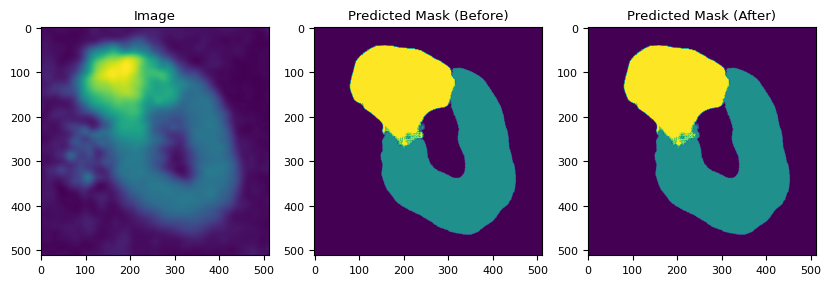

In [93]:
def turn_small_gem_regions_into_ring(image_512, predicted_mask, combined_predicted_mask):
    # Make a copy of the combined predicted mask
    combined_predicted_mask_copy = combined_predicted_mask.copy()
    gem_mask = combined_predicted_mask == 2

    # Find the largest gem region
    gem_labels = label(gem_mask)
    gem_regions = regionprops(gem_labels)
    gem_areas = [region.area for region in gem_regions]
    largest_gem_region = gem_regions[np.argmax(gem_areas)]

    # For all the other regions, check if they touch a ring region
    for region in gem_regions:
        if region.label == largest_gem_region.label:
            continue
        # Get only the pixels in the region
        region_mask = gem_labels == region.label
        # Dilate the region
        small_gem_dilation_strength = 5
        dilated_region_mask = region_mask
        for i in range(small_gem_dilation_strength):
            dilated_region_mask = binary_dilation(dilated_region_mask)
        # Get the intersection with the ring mask
        predicted_ring_mask = combined_predicted_mask == 1
        intersection = dilated_region_mask & predicted_ring_mask
        # If there is an intersection, then it is a ring
        if np.any(intersection):
            combined_predicted_mask[dilated_region_mask] = 1

    # Plot them side by side
    fig, ax = plt.subplots(1, 3, figsize=(10, 5))
    ax[0].imshow(image_512)
    ax[0].set_title("Image")
    ax[1].imshow(combined_predicted_mask_copy)
    ax[1].set_title("Predicted Mask (Before)")
    ax[2].imshow(combined_predicted_mask)
    ax[2].set_title("Predicted Mask (After)")
    plt.show()

    return combined_predicted_mask


combined_predicted_mask = turn_small_gem_regions_into_ring(
    image_512, predicted_mask, combined_predicted_mask
)

# Keep only largest ring region

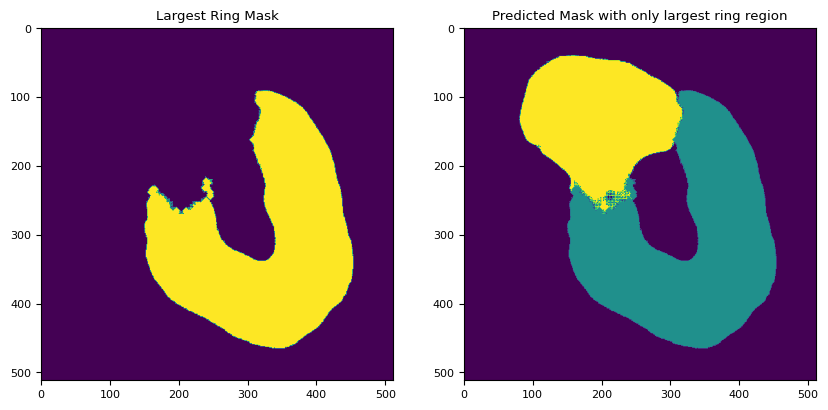

In [94]:
def remove_small_ring_regions(image_512, predicted_mask, combined_predicted_mask):
    # Keep only the largest ring region
    ring_mask = combined_predicted_mask == 1
    ring_mask_labelled = label(ring_mask)
    ring_props = regionprops(ring_mask_labelled)
    ring_areas = [region.area for region in ring_props]
    largest_ring_index = np.argmax(ring_areas)
    largest_ring_region = ring_props[largest_ring_index]
    largest_ring_mask = ring_mask_labelled == largest_ring_region.label

    combined_predicted_mask[combined_predicted_mask == 1] = 0
    combined_predicted_mask[largest_ring_mask] = 1

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(largest_ring_mask)
    ax[0].set_title("Largest Ring Mask")
    ax[1].imshow(combined_predicted_mask)
    ax[1].set_title("Predicted Mask with only largest ring region")
    plt.show()

    return combined_predicted_mask


combined_predicted_mask = remove_small_ring_regions(
    image_512, predicted_mask, combined_predicted_mask
)

## Dilate ring region but careful not to remove the two largest background regions

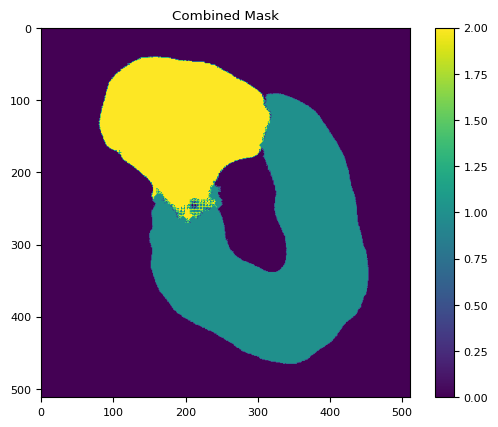

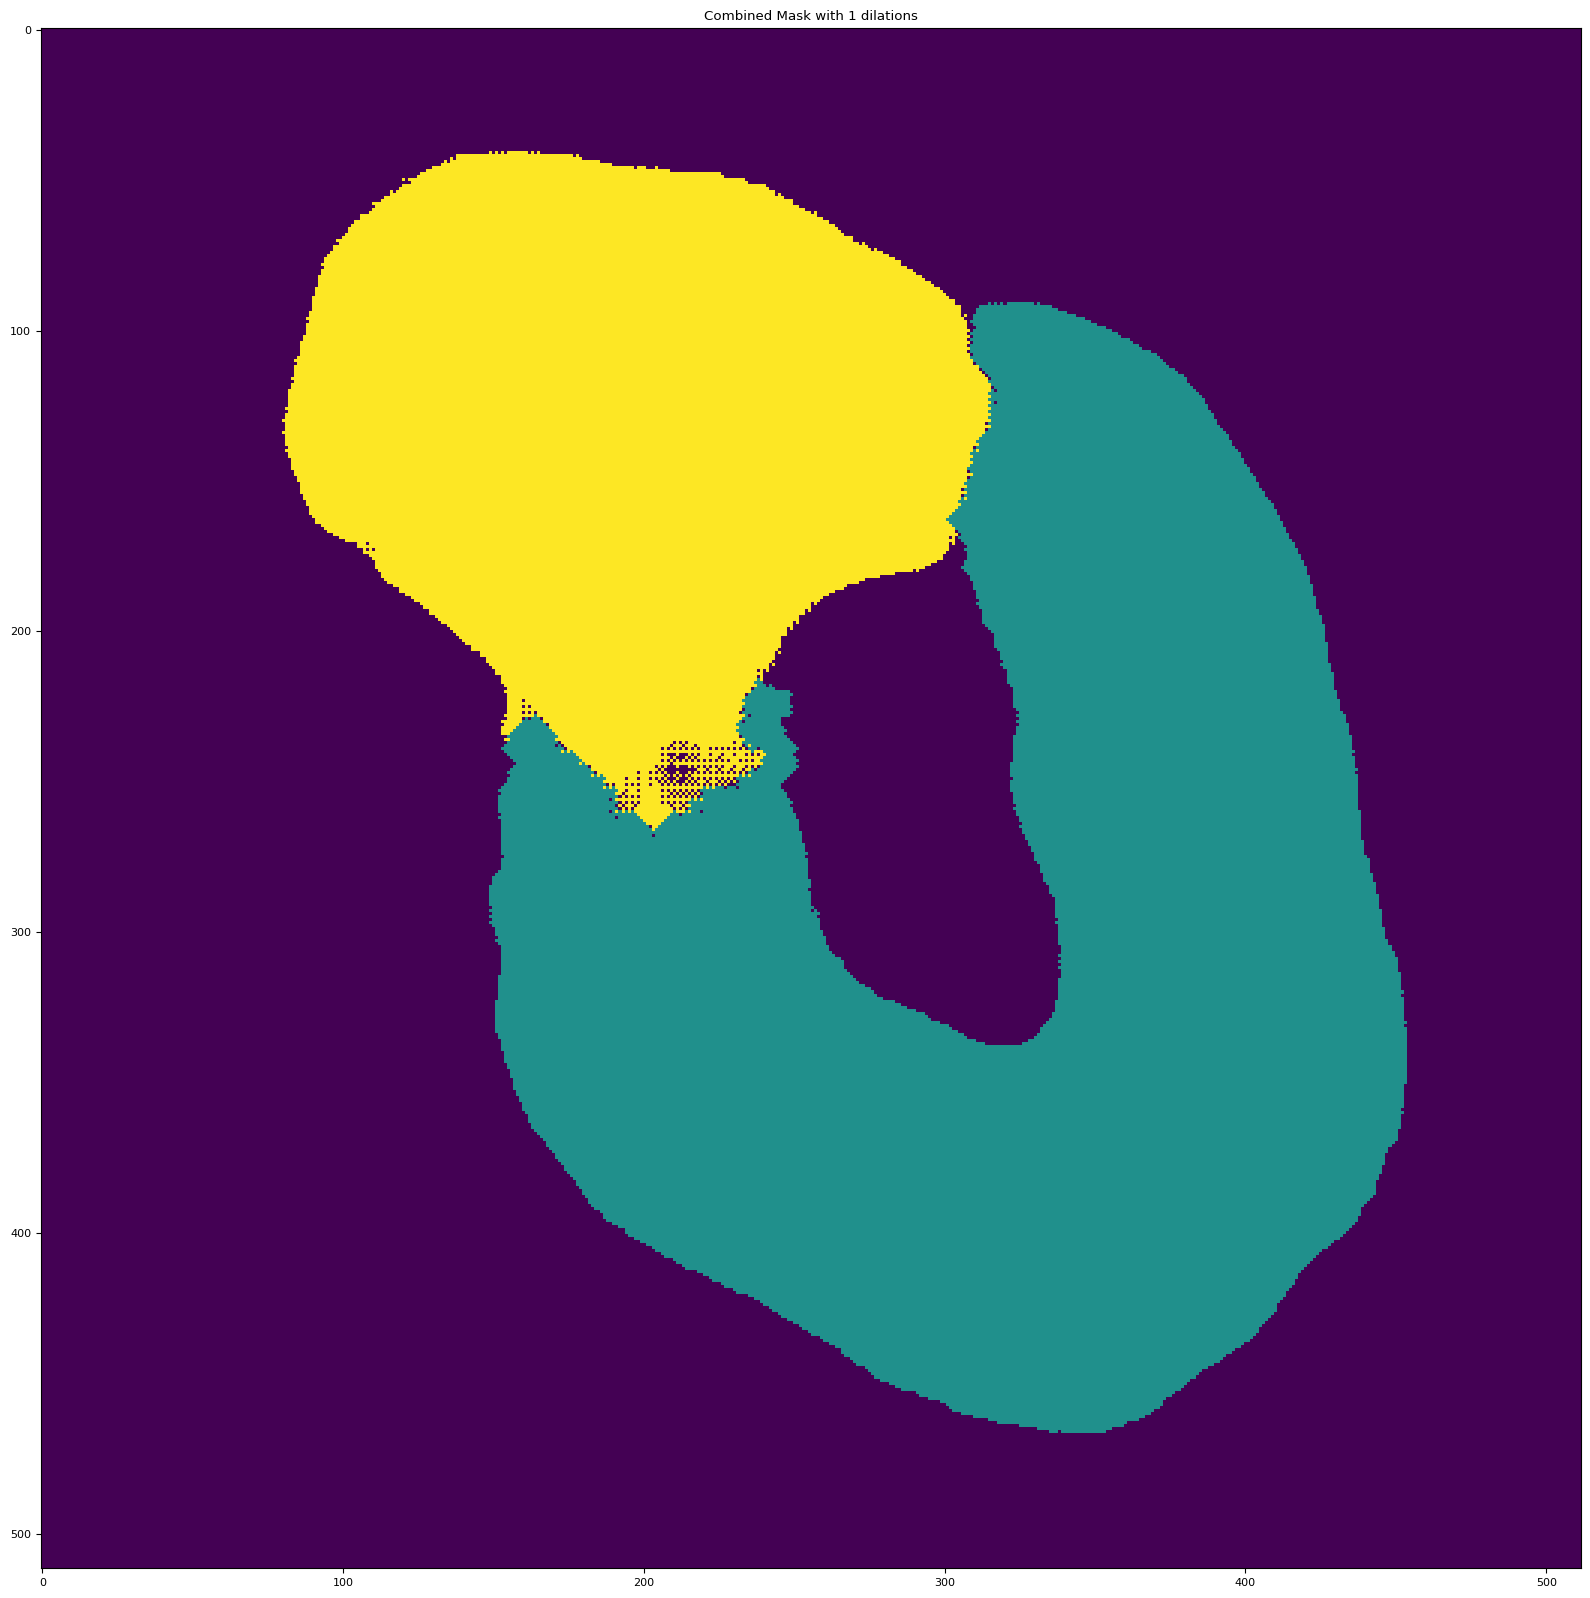

In [95]:
def ensure_connecting_ring_and_gem(image_512, predicted_mask, combined_predicted_mask):
    combined_mask = np.copy(combined_predicted_mask)

    # Plot combined mask
    plt.imshow(combined_mask)
    plt.title("Combined Mask")
    plt.colorbar()
    plt.show()

    # Calculate the number of background regions
    background_mask = combined_mask == 0
    background_labels = label(background_mask)
    background_props = regionprops(background_labels)
    background_areas = [region.area for region in background_props]
    num_background_regions = len(background_areas)

    # Iterate the dilation strength up from 1 to 10 until
    # it removes the second largest background region

    proposed_combined_mask = np.copy(combined_mask)
    for dilation_strength in range(1, 2):
        ring_mask = combined_mask == 1
        # Do the dilation multiple times
        ring_mask_dilated = np.copy(ring_mask)
        for i in range(dilation_strength):
            ring_mask_dilated = binary_dilation(ring_mask_dilated)
        # Apply the dilation to the combined mask
        proposed_combined_mask[ring_mask_dilated] = 1

        # Calculate the number of background regions
        background_mask = proposed_combined_mask == 0
        background_labels = label(background_mask)
        background_props = regionprops(background_labels)
        background_areas = [region.area for region in background_props]
        num_background_regions = len(background_areas)
        if num_background_regions < 2:
            break
        else:
            combined_mask = np.copy(proposed_combined_mask)

    fig, axs = plt.subplots(1, 1, figsize=(20, 20))
    axs.imshow(combined_mask)
    axs.set_title(f"Combined Mask with {dilation_strength} dilations")
    plt.show()

    return combined_mask


combined_predicted_mask = ensure_connecting_ring_and_gem(
    image_512, predicted_mask, combined_predicted_mask
)

# Remove small regions of background

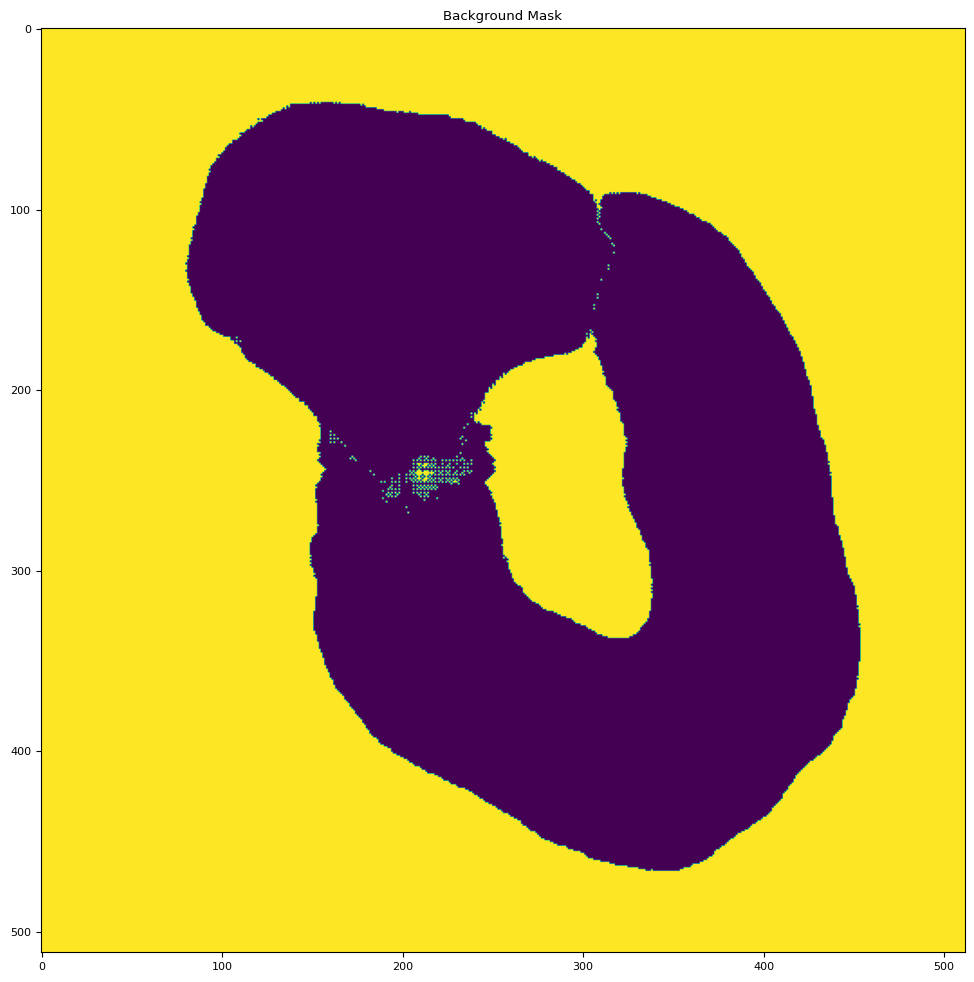

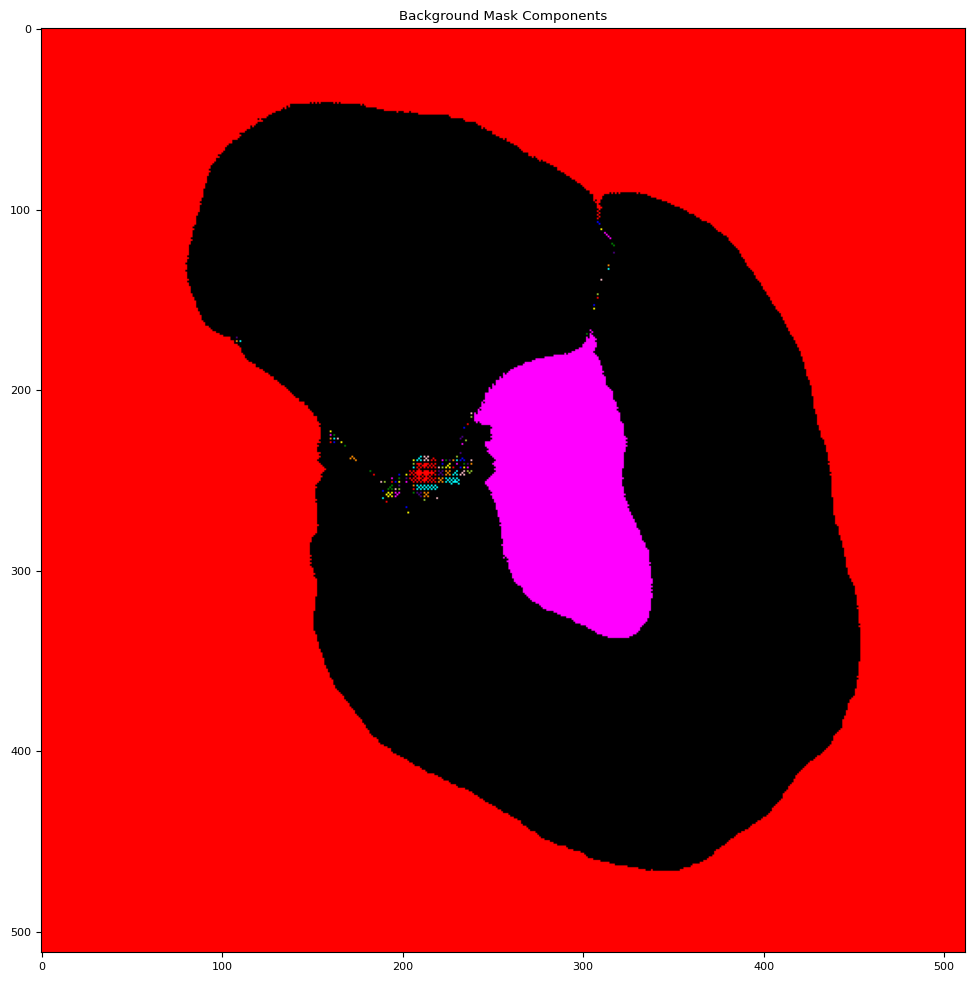

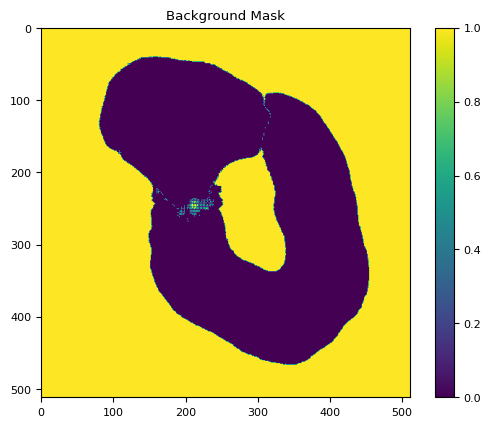

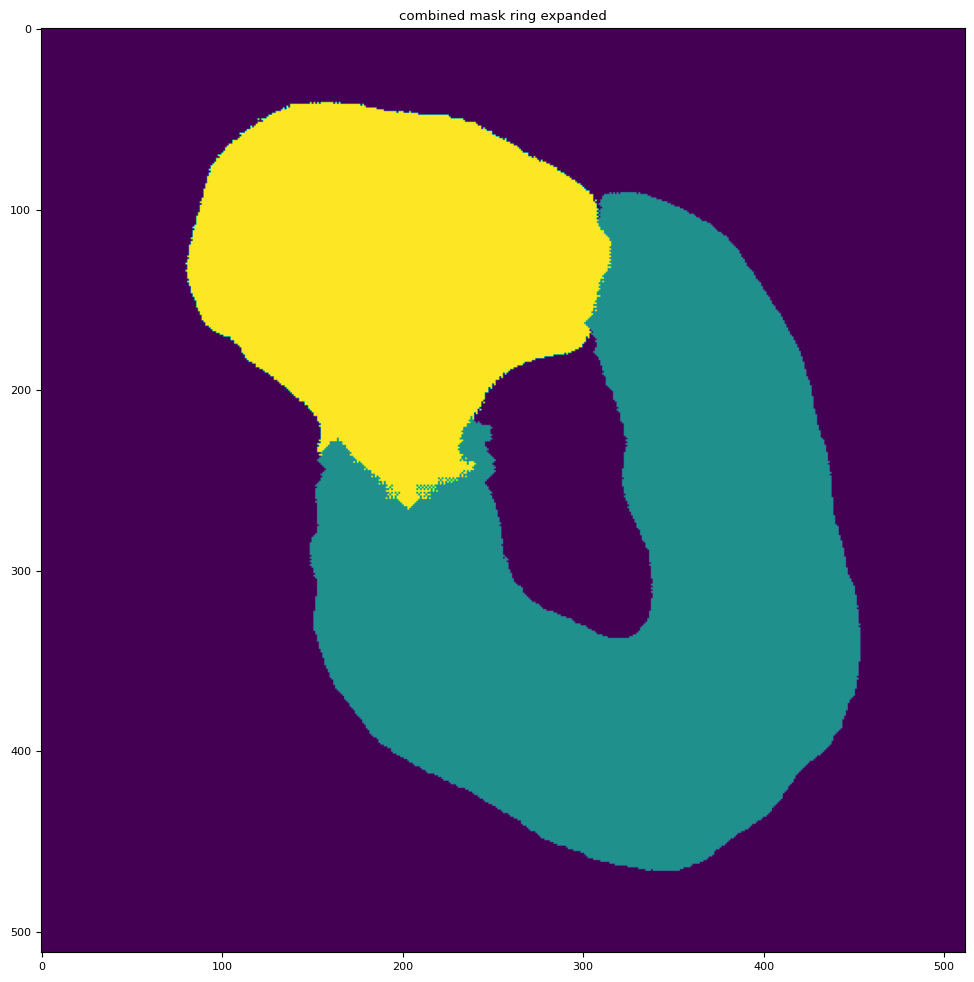

In [96]:
def remove_small_background_regions(image_512, predicted_mask, combined_predicted_mask):
    # Remove small regions of background
    background_mask = combined_predicted_mask == 0

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(background_mask)
    ax.set_title("Background Mask")
    plt.show()

    # Turn any regions that are smaller than a certain size into 1s
    background_mask_components = label(background_mask)
    background_mask_components_coloured = label2rgb(background_mask_components)
    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(background_mask_components_coloured)
    ax.set_title("Background Mask Components")
    plt.show()

    # Make a copy of the combined mask
    combined_mask_ring_expanded = np.copy(combined_predicted_mask)

    # Find the two largest background regions
    indexes_to_keep = []
    background_mask_properties = regionprops(background_mask_components)
    background_areas = [region.area for region in background_mask_properties]
    background_areas_sorted = np.sort(background_areas)
    # Get indexes of the two largest background regions
    # and add them to the indexes to keep
    indexes_to_keep.append(background_areas.index(background_areas_sorted[-1]))
    if len(background_areas_sorted) >= 2:
        indexes_to_keep.append(background_areas.index(background_areas_sorted[-2]))

    background_mask_properties = regionprops(background_mask_components)
    for index, region in enumerate(background_mask_properties):
        # print(f"Region: {index}, Area: {region.area}")

        # Only remove regions that are smaller than 200 pixels
        # and are not the two largest background regions
        if region.area < 200 and index not in indexes_to_keep:
            # If the region is touching any pixels that are in the ring mask, then set that region to be in the ring mask
            # Get the outline of the region by dilating the region and then subtracting the original region
            region_mask = background_mask_components == region.label
            region_mask_dilated = binary_dilation(region_mask)
            region_outline = np.logical_and(region_mask_dilated, np.invert(region_mask))
            # Get the pixels in the outline from the combined mask
            region_outline_pixel_values = combined_predicted_mask[region_outline]
            # print(f'region outline pixel values: {region_outline_pixel_values[0:10]}')
            # If any of the pixels in the outline are in the ring mask (ie are 1s) then set the region to be in the ring mask
            # Check if there are any pixels with value 1 in the outline
            if np.any(region_outline_pixel_values == 1):
                # Set the region to be in the ring mask
                combined_mask_ring_expanded[background_mask_components == region.label] = 1
            else:
                # Set the region to be in the gem mask
                combined_mask_ring_expanded[background_mask_components == region.label] = 2

    plt.imshow(background_mask)
    plt.title("Background Mask")
    plt.colorbar()
    plt.show()

    fig, ax = plt.subplots(figsize=(12, 12))
    ax.imshow(combined_mask_ring_expanded)
    ax.set_title("combined mask ring expanded")
    plt.show()

    return combined_mask_ring_expanded


combined_predicted_mask = remove_small_background_regions(
    image_512, predicted_mask, combined_predicted_mask
)

# Find connecting regions between ring and gem

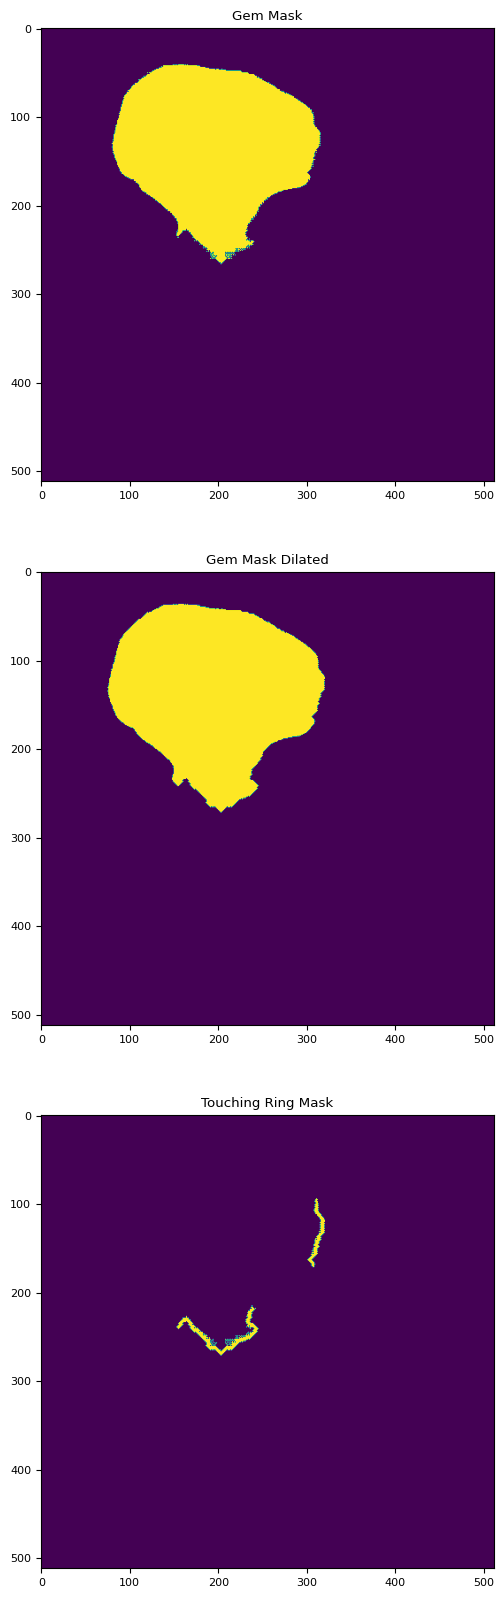

In [97]:
def find_connecting_regions(image_512, predicted_mask, combined_predicted_mask):
    # Take the gem mask and dilate it
    gem_mask = combined_predicted_mask == 2
    ring_mask = combined_predicted_mask == 1
    near_gem_ring_dilation_strength = 5
    gem_mask_dilated = np.copy(gem_mask)
    for i in range(near_gem_ring_dilation_strength):
        gem_mask_dilated = binary_dilation(gem_mask_dilated)

    # Find the pixels in the dilation that are also in the ring mask
    near_gem_and_ring = np.logical_and(gem_mask_dilated, ring_mask)

    fig, axs = plt.subplots(3, 1, figsize=(60, 20))
    axs[0].imshow(gem_mask)
    axs[0].set_title("Gem Mask")
    axs[1].imshow(gem_mask_dilated)
    axs[1].set_title("Gem Mask Dilated")
    axs[2].imshow(near_gem_and_ring)
    axs[2].set_title("Touching Ring Mask")
    plt.show()

    return near_gem_and_ring


near_gem_and_ring = find_connecting_regions(image_512, predicted_mask, combined_predicted_mask)

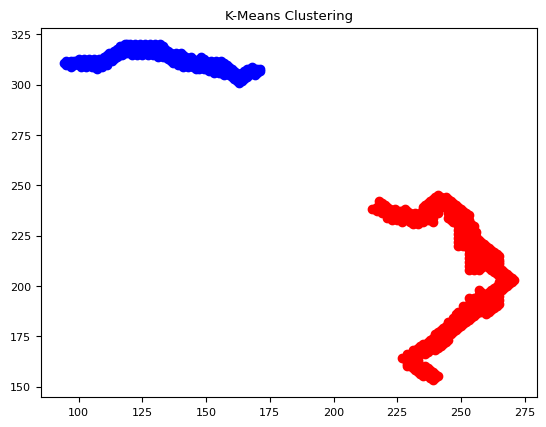

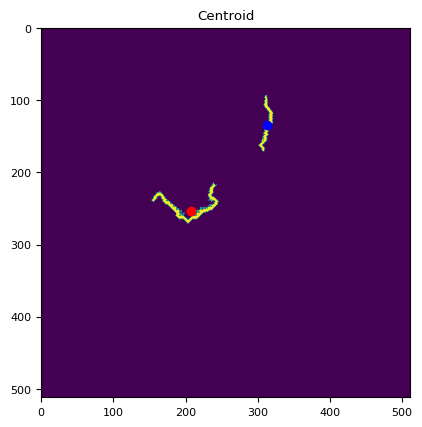

In [98]:
def find_centroids_of_connecting_regions(
    image_512, predicted_mask, combined_predicted_mask, near_gem_and_ring
):
    ## Find the midpoint of each of the two intersection regions

    # Cluster the points into two groups, one for each intersection region
    # Use the k-means algorithm to cluster the points into two groups

    # Get the coordinates of the points
    coordinates = np.argwhere(near_gem_and_ring)
    # Cluster the points
    kmeans = KMeans(n_clusters=2, random_state=0).fit(coordinates)
    # Get mask of each cluster
    cluster1_mask = kmeans.labels_ == 0
    cluster2_mask = kmeans.labels_ == 1
    # Plot the clusters
    plt.scatter(coordinates[cluster1_mask, 0], coordinates[cluster1_mask, 1], c="red")
    plt.scatter(coordinates[cluster2_mask, 0], coordinates[cluster2_mask, 1], c="blue")
    plt.title("K-Means Clustering")
    plt.show()

    # For each cluster:
    centroid_1 = np.mean(coordinates[cluster1_mask, :], axis=0)
    centroid_2 = np.mean(coordinates[cluster2_mask, :], axis=0)

    # Find the closest point in the other cluster to each centroid
    # Get the coordinates of each cluster
    cluster1_coordinates = coordinates[cluster1_mask, :]
    # Get the distance between each point in cluster 1 and the centroid of cluster 1
    distances_1 = np.linalg.norm(cluster1_coordinates - centroid_1, axis=1)
    # Get the index of the closest point
    closest_point_index_1 = np.argmin(distances_1)
    # Get the coordinates of the closest point
    closest_point_1 = cluster1_coordinates[closest_point_index_1, :]
    centroid_1 = closest_point_1

    # Get the coordinates of each cluster
    cluster2_coordinates = coordinates[cluster2_mask, :]
    # Get the distance between each point in cluster 2 and the centroid of cluster 2
    distances_2 = np.linalg.norm(cluster2_coordinates - centroid_2, axis=1)
    # Get the index of the closest point
    closest_point_index_2 = np.argmin(distances_2)
    # Get the coordinates of the closest point
    closest_point_2 = cluster2_coordinates[closest_point_index_2, :]
    centroid_2 = closest_point_2

    # Plot the centroids with the cluster
    plt.imshow(near_gem_and_ring)
    plt.scatter(centroid_1[1], centroid_1[0], c="red")
    plt.scatter(centroid_2[1], centroid_2[0], c="blue")
    plt.title("Centroid")
    plt.show()

    return centroid_1, centroid_2


centroid_1, centroid_2 = find_centroids_of_connecting_regions(
    image_512, predicted_mask, combined_predicted_mask, near_gem_and_ring
)

Ring Pixel Image Shape: (512, 512)
Maximum Pixel Value: 0.5235490202903748 Minimum Pixel Value: 0.0


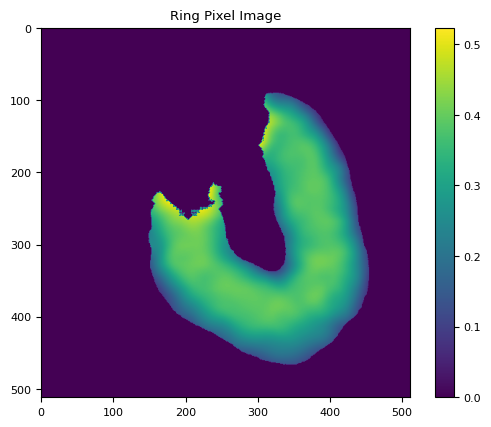

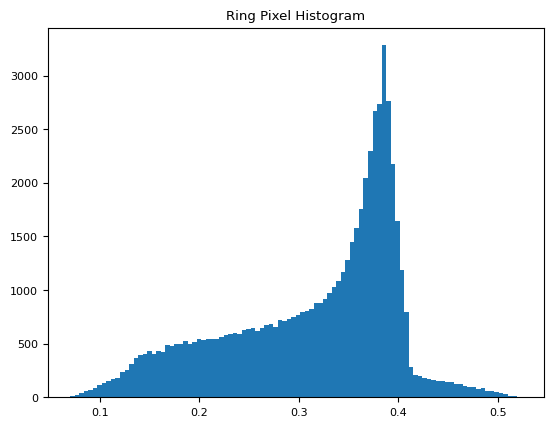

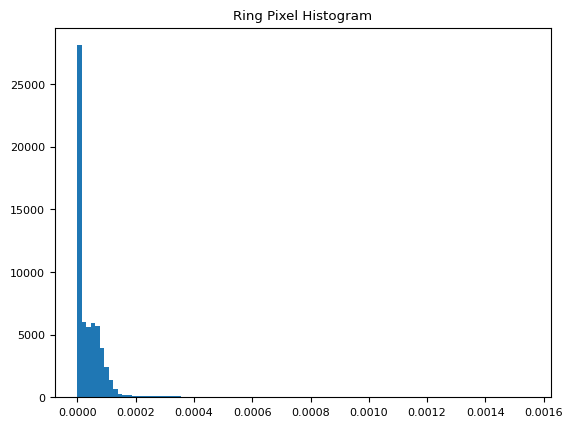

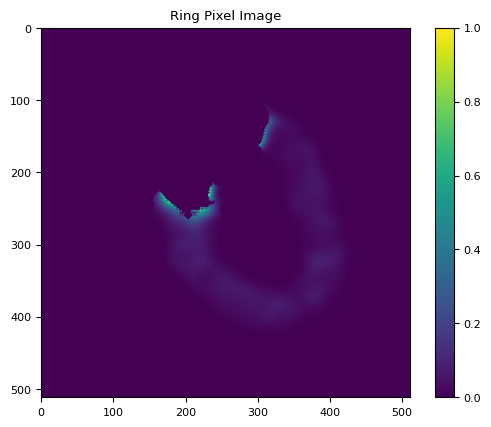

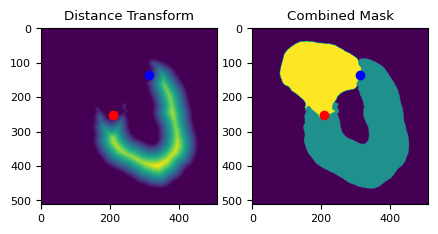

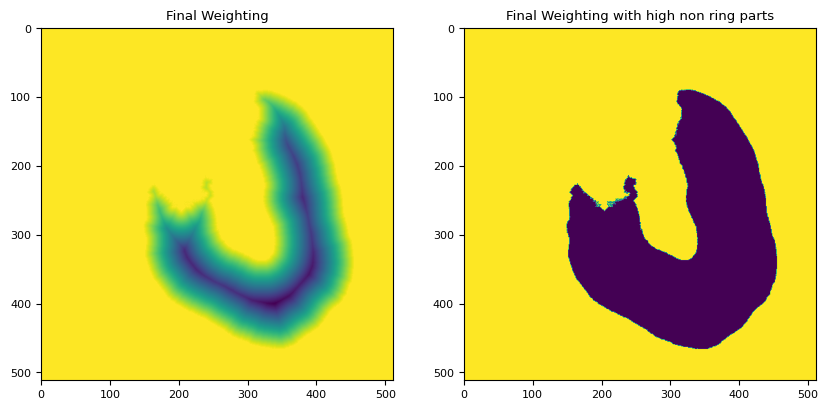

In [99]:
def create_pathdinging_weighting(
    image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2
):
    ring_mask = combined_predicted_mask == 1

    # Get the pixels in the image that are in the mask
    ring_pixels = image_512[ring_mask]

    # Create an array of zeros the same size as the image
    ring_pixel_image = np.zeros_like(image_512)
    # Set the pixels in the mask to be the pixels from the image
    ring_pixel_image[ring_mask] = ring_pixels

    print(f"Ring Pixel Image Shape: {ring_pixel_image.shape}")
    print(
        f"Maximum Pixel Value: {np.max(ring_pixel_image)} Minimum Pixel Value: {np.min(ring_pixel_image)}"
    )

    ring_pixel_image = ring_pixel_image - np.min(ring_pixel_image)

    plt.imshow(ring_pixel_image)
    plt.title("Ring Pixel Image")
    plt.colorbar()
    plt.show()

    # Plot kde of ring pixels
    ring_pixels = ring_pixel_image[ring_mask]
    plt.hist(ring_pixels, bins=100)
    plt.title("Ring Pixel Histogram")
    plt.show()

    # Increase the contrast of the image
    ring_pixel_image = ring_pixel_image**10

    # Plot kde of ring pixels
    ring_pixels = ring_pixel_image[ring_mask]
    plt.hist(ring_pixels, bins=100)
    plt.title("Ring Pixel Histogram")
    plt.show()

    # Normalise the image
    ring_pixel_image = ring_pixel_image - np.min(ring_pixel_image)
    ring_pixel_image = ring_pixel_image / np.max(ring_pixel_image)

    plt.imshow(ring_pixel_image)
    plt.colorbar()
    plt.title("Ring Pixel Image")
    plt.show()

    # Create a distance transform of the ring mask
    distance_transform = distance_transform_edt(ring_mask)

    # Normalise the distance transform
    distance_transform = distance_transform - np.min(distance_transform)
    distance_transform = distance_transform / np.max(distance_transform)

    # Overlay the centroids on the distance transform beside the combined mask
    fig, axs = plt.subplots(1, 2, figsize=(5, 10))
    axs[0].imshow(distance_transform)
    axs[0].scatter(centroid_1[1], centroid_1[0], c="red")
    axs[0].scatter(centroid_2[1], centroid_2[0], c="blue")
    axs[0].set_title("Distance Transform")
    axs[1].imshow(combined_predicted_mask)
    axs[1].scatter(centroid_1[1], centroid_1[0], c="red")
    axs[1].scatter(centroid_2[1], centroid_2[0], c="blue")
    axs[1].set_title("Combined Mask")
    plt.show()

    # Combine the distance transform and the ring pixel image to get a final weighting
    distance_weighting_factor = 1.0

    final_weighting = (
        distance_weighting_factor * distance_transform
        + (1 - distance_weighting_factor) * ring_pixel_image
    )

    # Normalise
    final_weighting = final_weighting - np.min(final_weighting)
    final_weighting = final_weighting / np.max(final_weighting)

    # Invert the weighting
    final_weighting = 1 - final_weighting

    fig, ax = plt.subplots(1, 2, figsize=(10, 20))
    ax[0].imshow(final_weighting)
    ax[0].set_title("Final Weighting")
    # Set the non ring parts to be very high
    final_weighting_high_outside = np.copy(final_weighting)
    final_weighting_high_outside[combined_predicted_mask != 1] = 1000
    ax[1].imshow(final_weighting_high_outside)
    ax[1].set_title("Final Weighting with high non ring parts")
    plt.show()

    return final_weighting, final_weighting_high_outside


pathfinding_weighting_visualisation, final_weighting = create_pathdinging_weighting(
    image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2
)

weight: 141.24954462159175


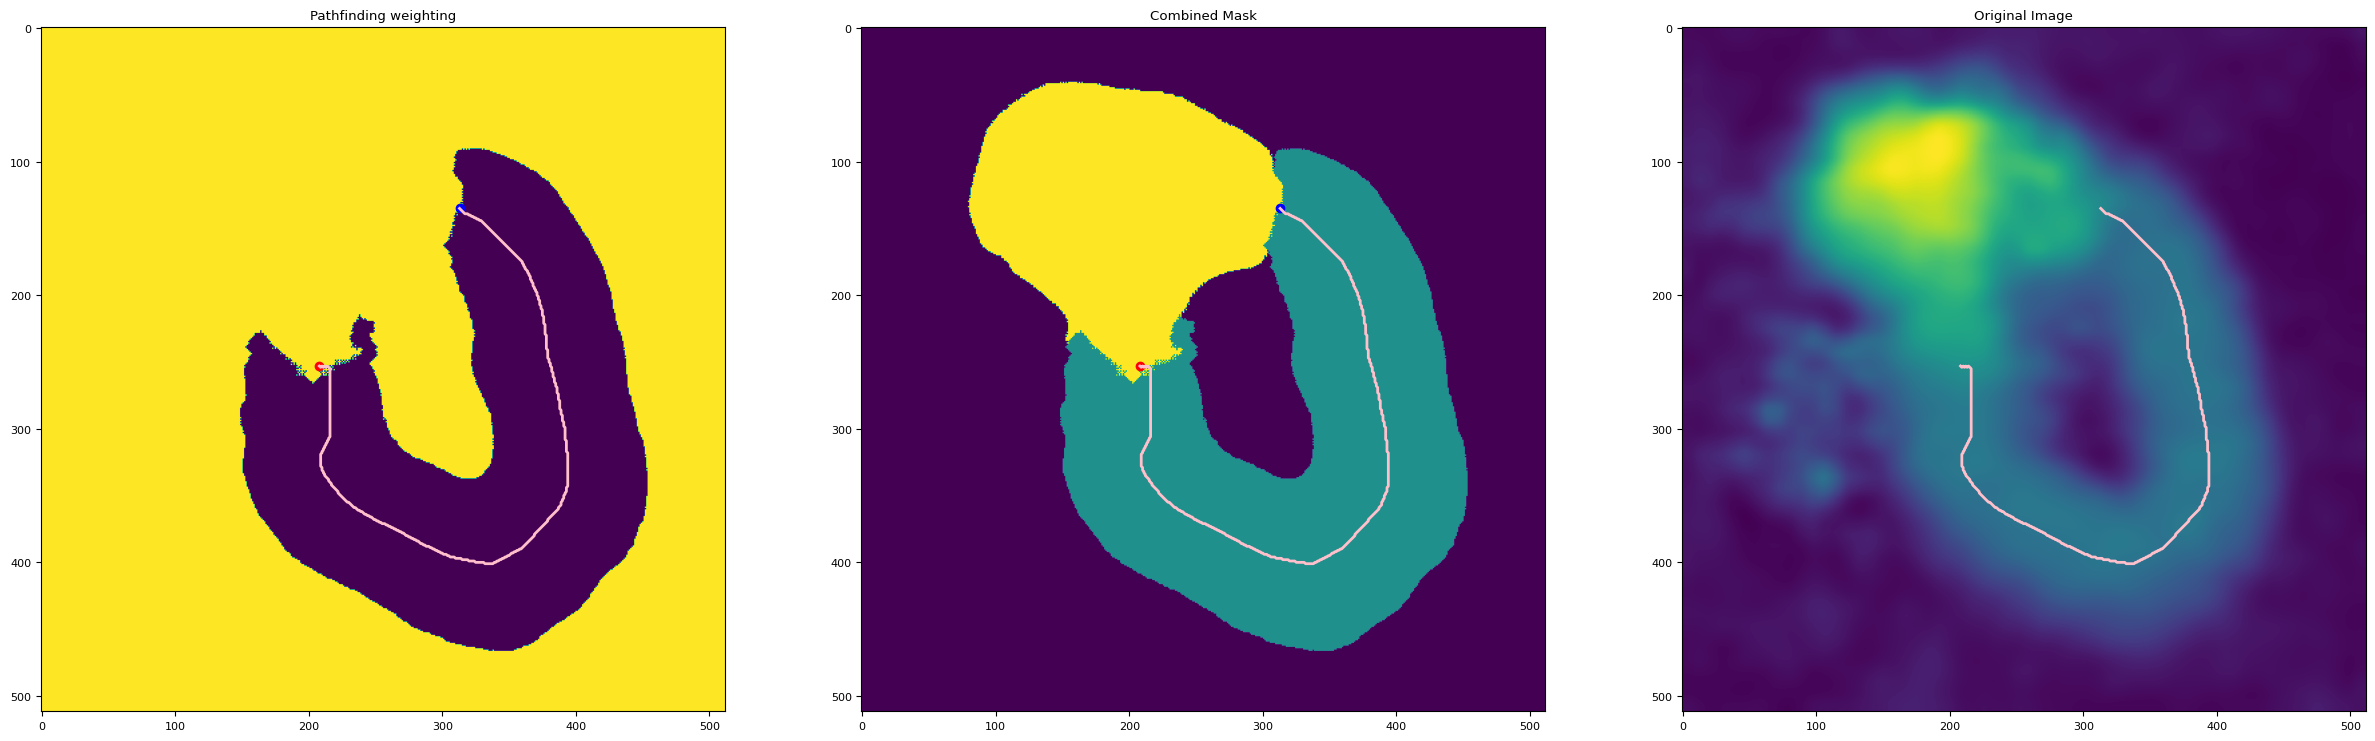

In [100]:
def find_path(
    image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2, final_weighting
):
    # Use a weighted pathfinding algorithm to find the best path between the two centroids,
    # with the distance transform as the weight map
    from skimage.graph import route_through_array

    # Get the path
    path, weight = route_through_array(
        final_weighting, centroid_1, centroid_2, fully_connected=True, geometric=True
    )

    path = np.stack(path, axis=-1)

    print(f"weight: {weight}")

    # Plot the path
    fig, axs = plt.subplots(1, 3, figsize=(30, 16))
    axs[0].imshow(final_weighting)
    axs[0].scatter(centroid_1[1], centroid_1[0], c="red")
    axs[0].scatter(centroid_2[1], centroid_2[0], c="blue")
    axs[0].plot(path[1], path[0], linewidth=2, c="pink")
    axs[0].set_title("Pathfinding weighting")
    axs[1].imshow(combined_predicted_mask)
    axs[1].scatter(centroid_1[1], centroid_1[0], c="red")
    axs[1].scatter(centroid_2[1], centroid_2[0], c="blue")
    axs[1].plot(path[1], path[0], linewidth=2, c="pink")
    axs[1].set_title("Combined Mask")
    axs[2].imshow(image_512)
    axs[2].plot(path[1], path[0], linewidth=2, c="pink")
    axs[2].set_title("Original Image")
    plt.show()

    # Create binary image of path
    path_image = np.zeros_like(image_512)
    path_image[path[0], path[1]] = 1

    return path_image, path


path_image, path = find_path(
    image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2, final_weighting
)

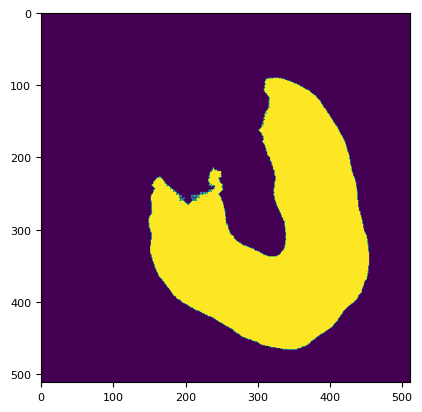

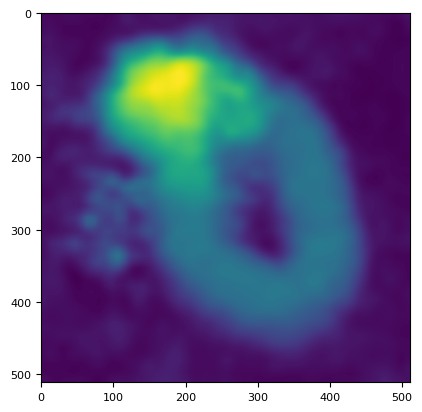

gaussian: -1080px
PRUNE:  [0.46543768 0.39080793 0.44597444]
THRESH:  0.3925591 0.85 -0.4574408888816833
[Thu, 14 Dec 2023 12:51:37] [INFO    ] [topostats] Node Stats - Processing Grain: 1
[Thu, 14 Dec 2023 12:51:37] [INFO    ] [topostats] [test] : Compiling the trace.
[Thu, 14 Dec 2023 12:51:37] [INFO    ] [topostats] [test] Getting coordinate trace
Mols in trace: 1
[Thu, 14 Dec 2023 12:51:37] [INFO    ] [topostats] [test] : Grain 1 ordered via nodeStats.
[Thu, 14 Dec 2023 12:51:37] [INFO    ] [topostats] [test] : Grain 1 has 1 molecules.


In [101]:
# Skeletonize the ring mask using Max's method
ring_mask = combined_predicted_mask == 1
plt.imshow(ring_mask)
plt.show()

plt.imshow(image_512)
plt.show()

from topostats.tracing.dnatracing import trace_grain

# Get the skeleton of the ring mask

dnatracing_config = {
    "min_skeleton_size": 10,
    "skeletonisation_params": {
        "skeletonisation_method": "joe",
        "height_bias": 0.6,
    },
    "pruning_params": {
        "pruning_method": "joe",
        "max_length": -1,
        "method_values": "mid",
        "method_outlier": "abs_mean",
        "height_threshold": 0.85,
    },
    "pad_width": 20,
}

results, node_dict, node_image_dict, images, trace = trace_grain(
    cropped_image=image_512,
    cropped_mask=ring_mask,
    pixel_to_nm_scaling=1,
    skeletonisation_params=dnatracing_config["skeletonisation_params"],
    pruning_params=dnatracing_config["pruning_params"],
    filename="test",
    min_skeleton_size=10,
    n_grain=1,
)

<class 'list'>
<class 'dict'>
dict_keys(['image', 'grain', 'smoothed_grain', 'skeleton', 'pruned_skeleton', 'node_img', 'ordered_traces', 'fitted_traces', 'visual'])
image
(512, 512)


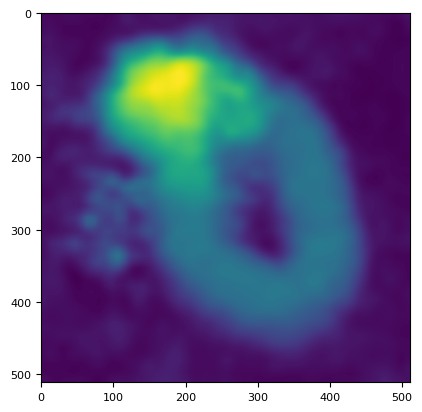

grain
(512, 512)


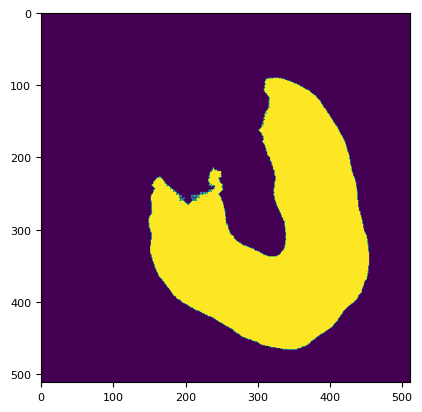

smoothed_grain
(512, 512)


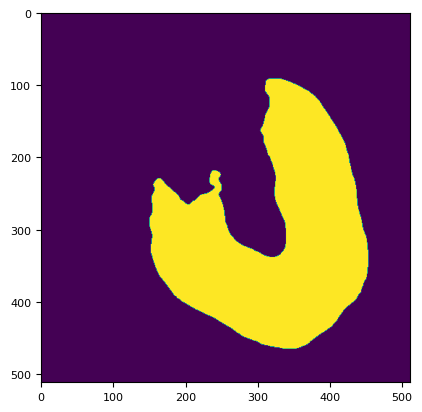

skeleton
(512, 512)


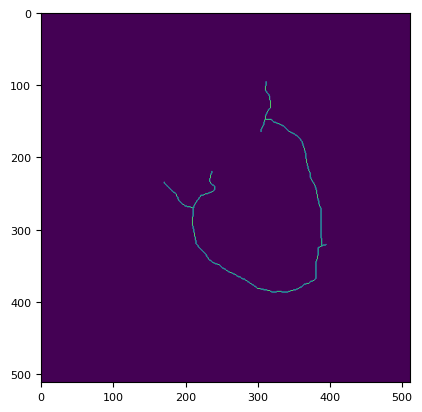

pruned_skeleton
(512, 512)


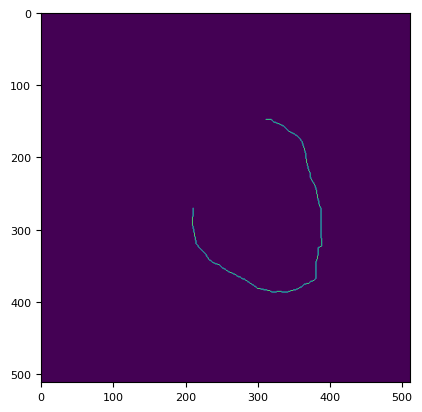

node_img
(512, 512)


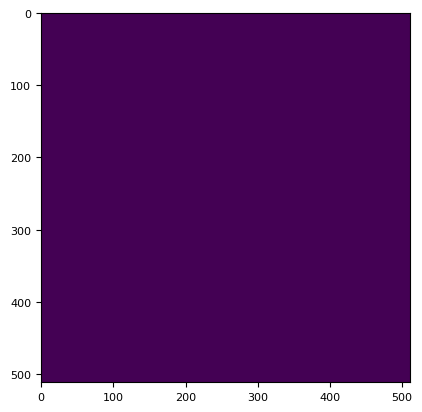

ordered_traces
(512, 512)


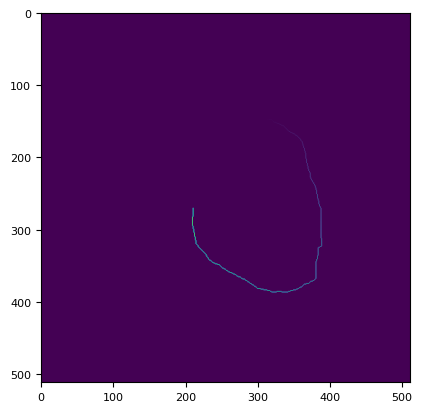

fitted_traces
(512, 512)


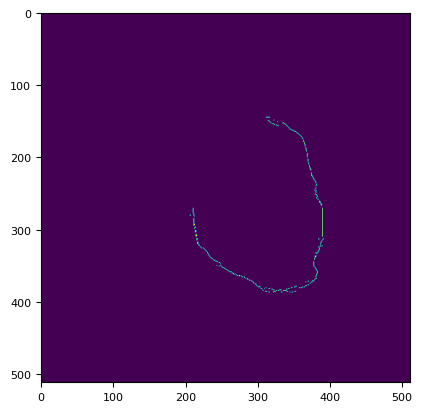

visual
(512, 512)


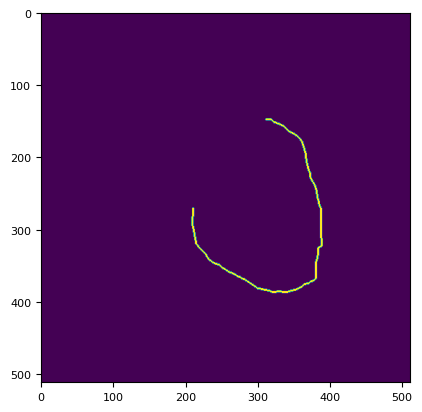

In [102]:
%matplotlib inline

print(type(trace))
print(type(images))
print(images.keys())

for key in images.keys():
    if type(images[key]) == np.ndarray:
        print(key)
        print(images[key].shape)
        plt.imshow(images[key])
        plt.show()

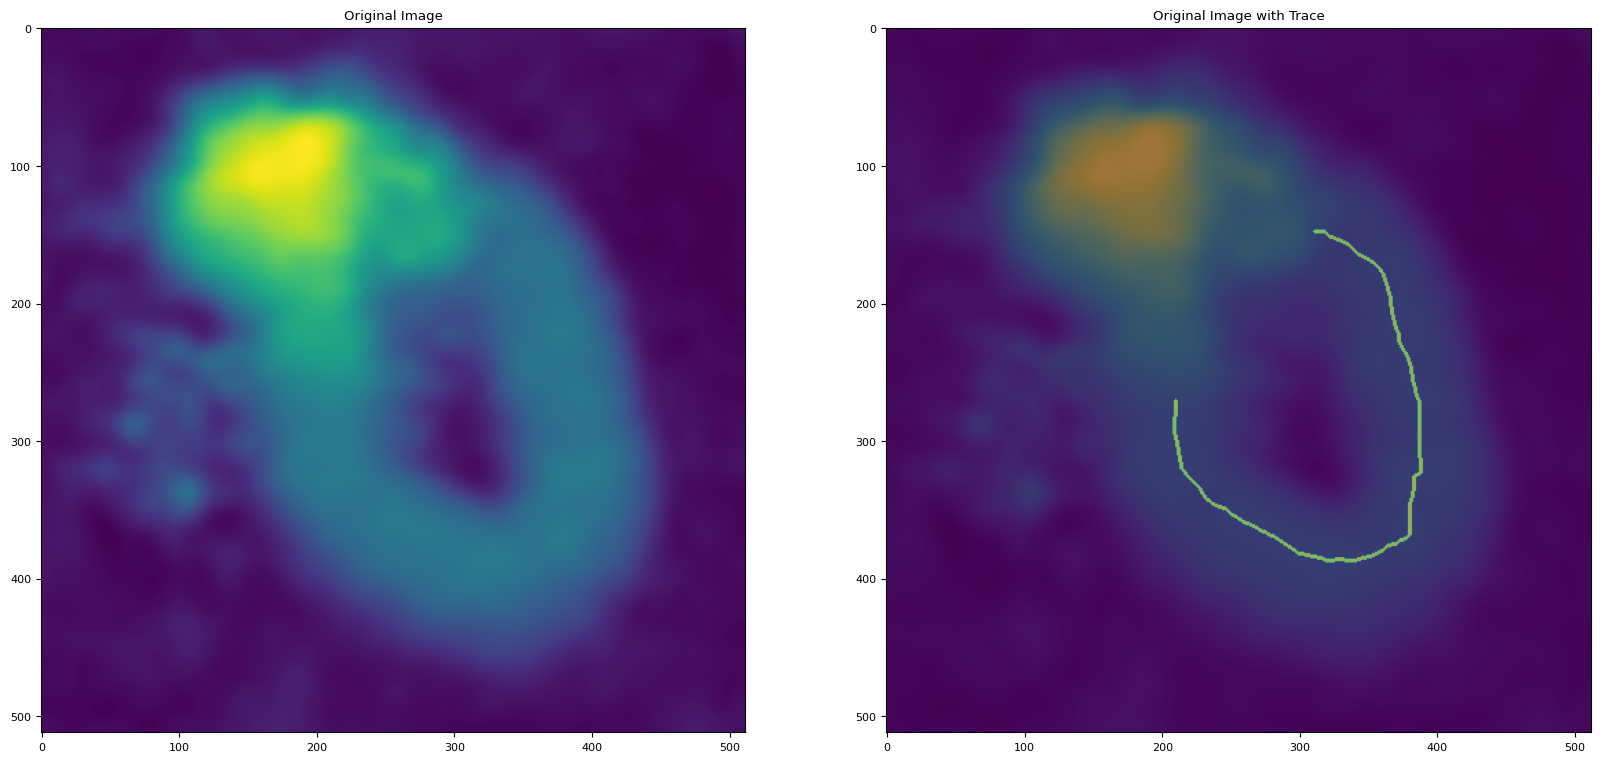

In [103]:
# Plot visual over original image, where the trace is the image "visual" in the images dictionary

fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].imshow(image_512)
axs[0].set_title("Original Image")
axs[1].imshow(image_512)
axs[1].imshow(images["visual"], alpha=0.5)
axs[1].set_title("Original Image with Trace")
plt.show()

In [104]:
# # Try Max's skeletonisation method

# def binary_thin_check_a():


# def get_local_pixels_binary(point: tuple, mask: np.ndarray):
#     local_pixels = mask[point[0] - 1 : point[0] + 2, point[1] - 1 : point[1] + 2].flatten()
#     return np.delete(local_pixels, 4)

# def delete_pixel_subit_1(point: tuple, mask: np.ndarray):
#     p7, p8, p9, p6, p2, p5, p4, p3 = get_local_pixels_binary(point, mask)


# def skeletonize_iteration(mask: np.ndarray, image: np.ndarray):
#     more_skeletonized_mask = np.copy(mask)
#     pixels_to_delete = []

#     # Sub iteration 1: binary check
#     mask_coordinates = np.argwhere(mask == 1).tolist()
#     for point in mask_coordinates:
#         #

# def skeletonize(mask: np.ndarray, image: np.ndarray):

#     converged = False
#     counter = 0
#     while not converged:
#         counter += 1
#         image, converged = skeletonize_iteration(image)

## Run on all molecules

1/1 [==============================] - 0s 18ms/step


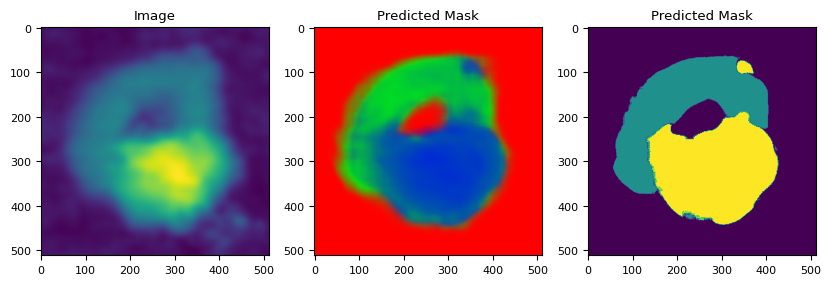

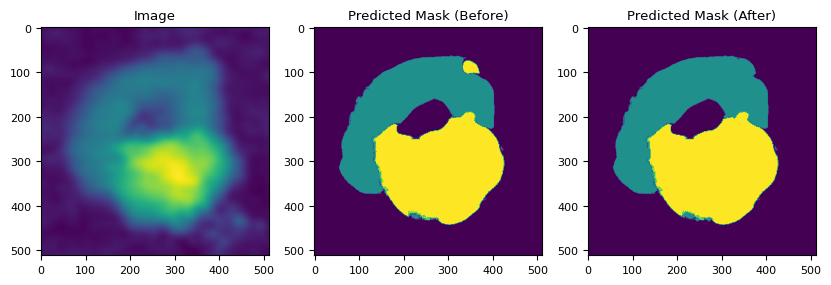

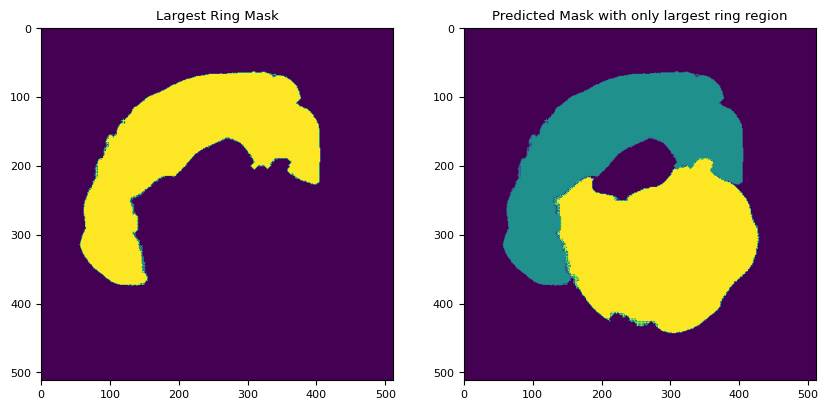

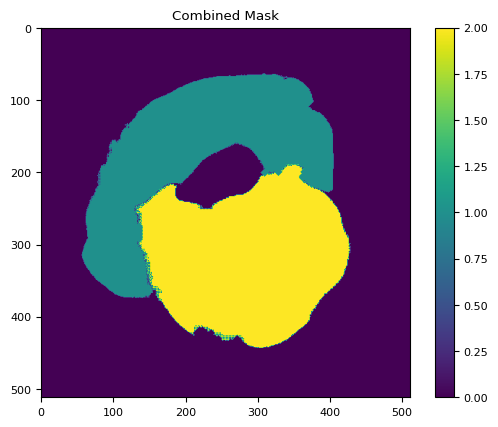

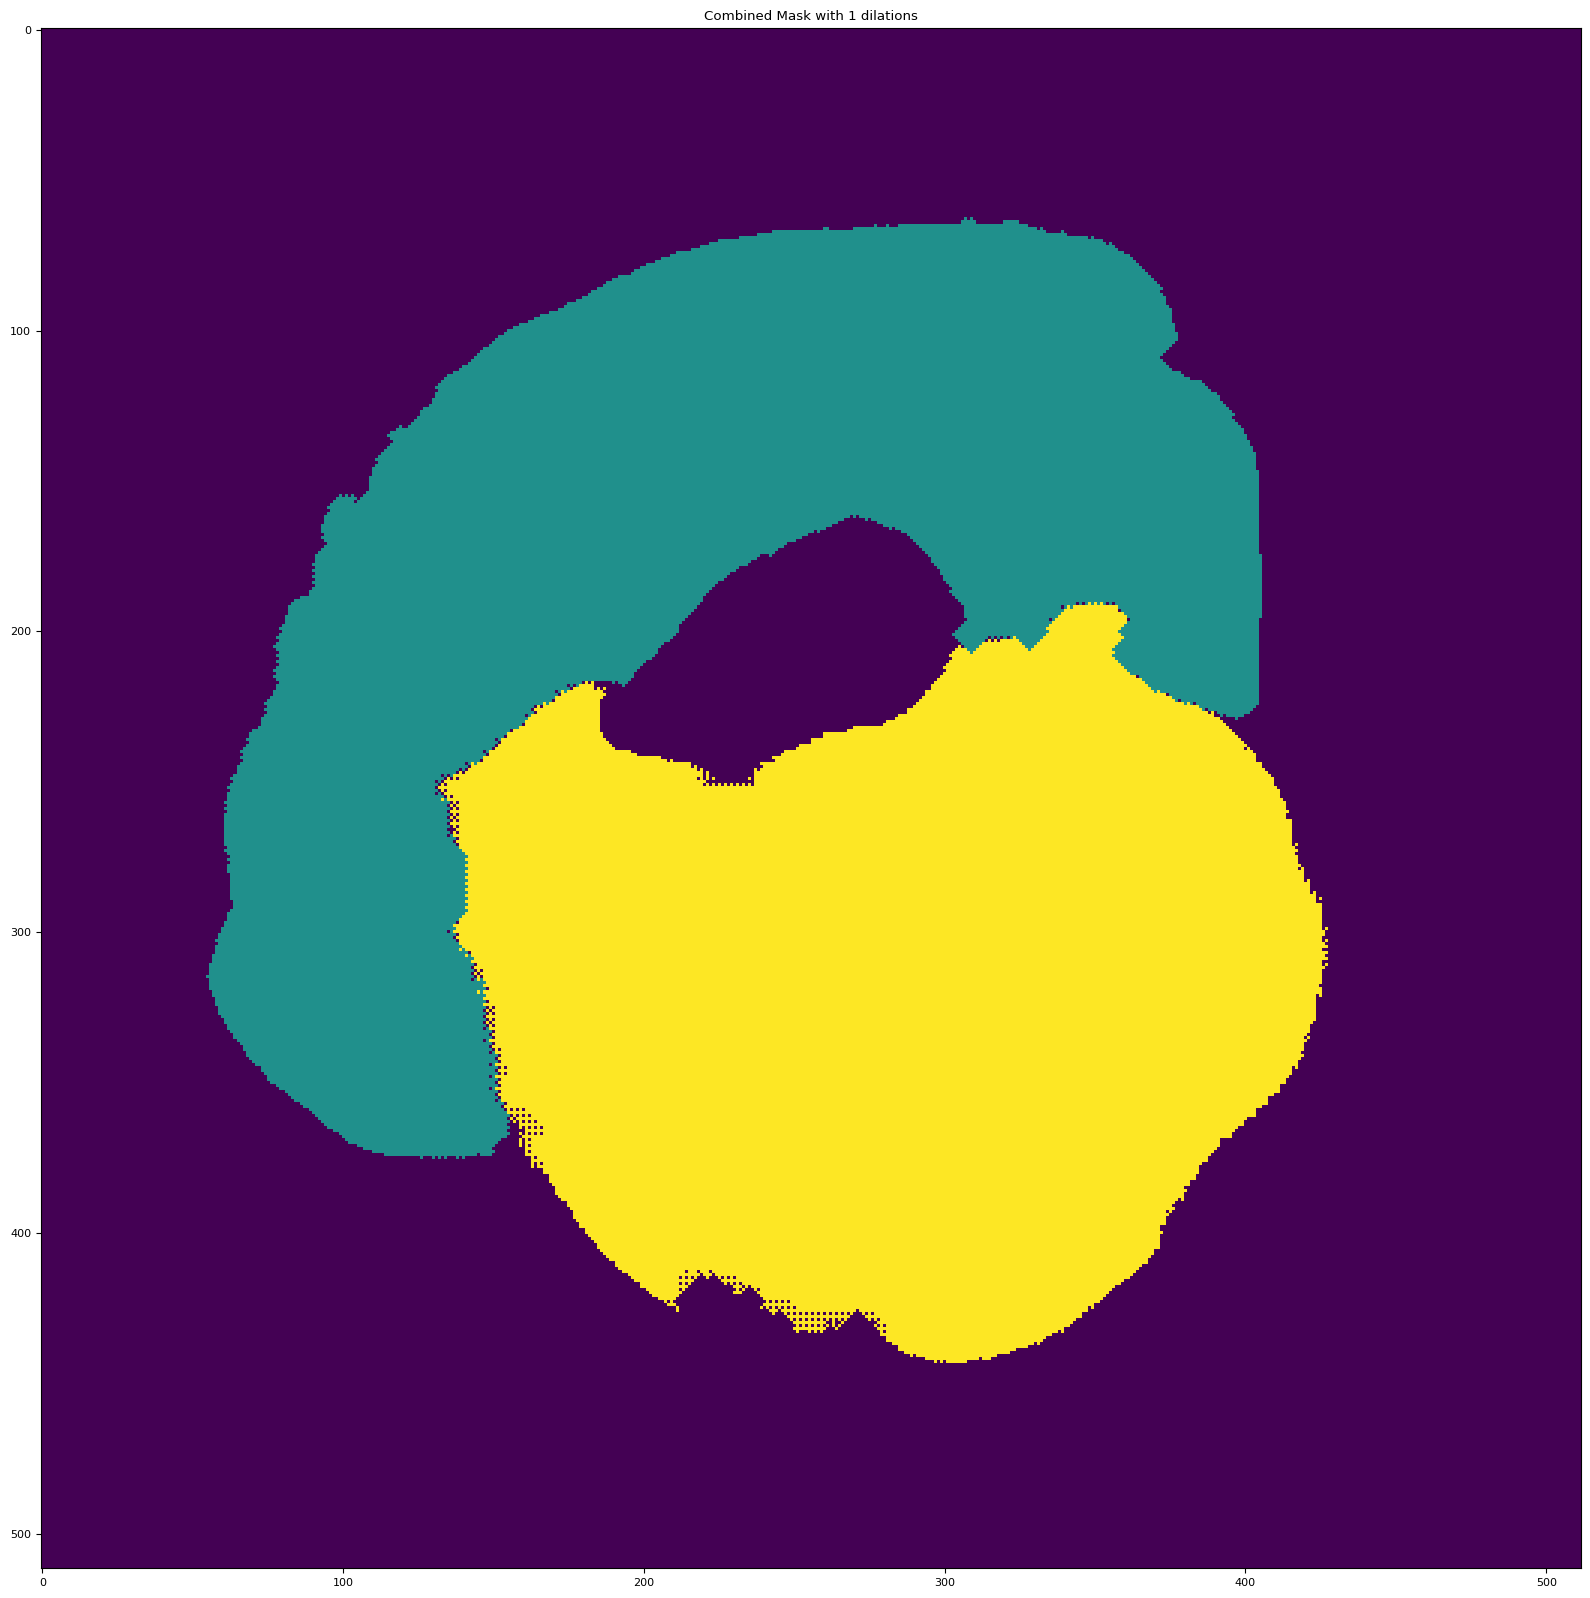

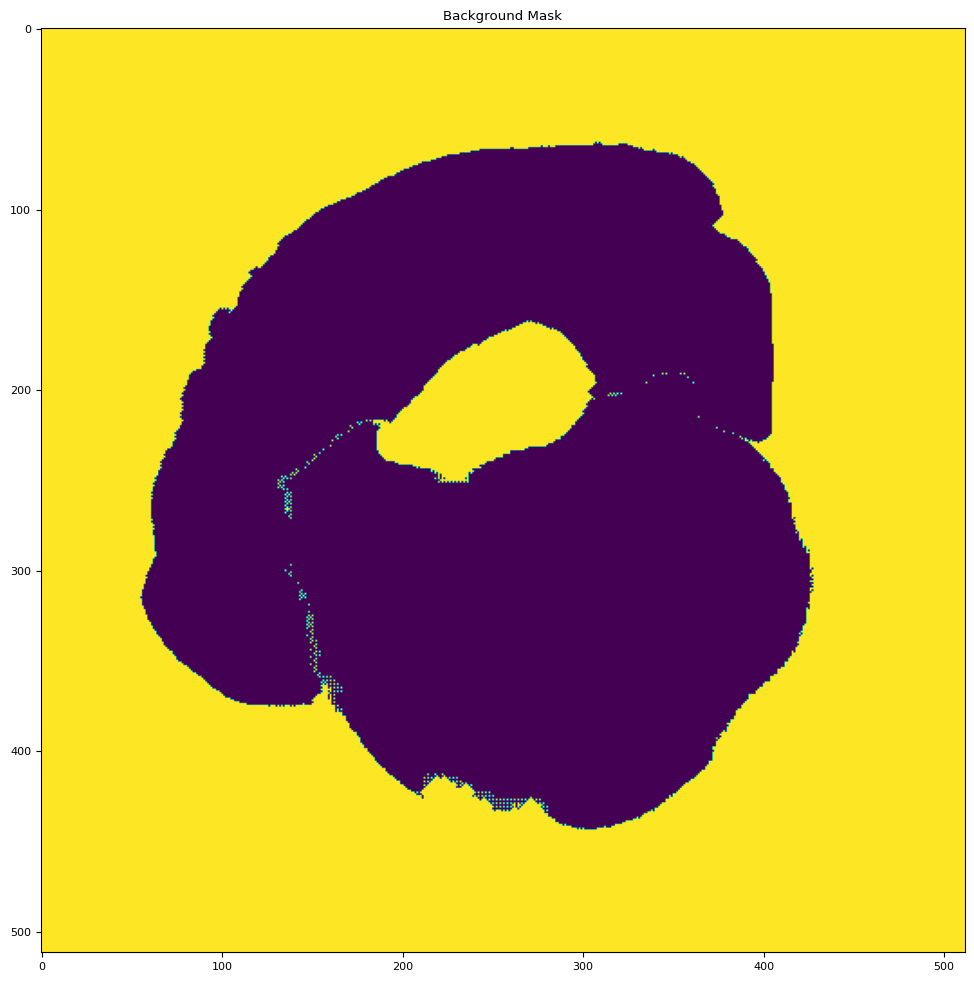

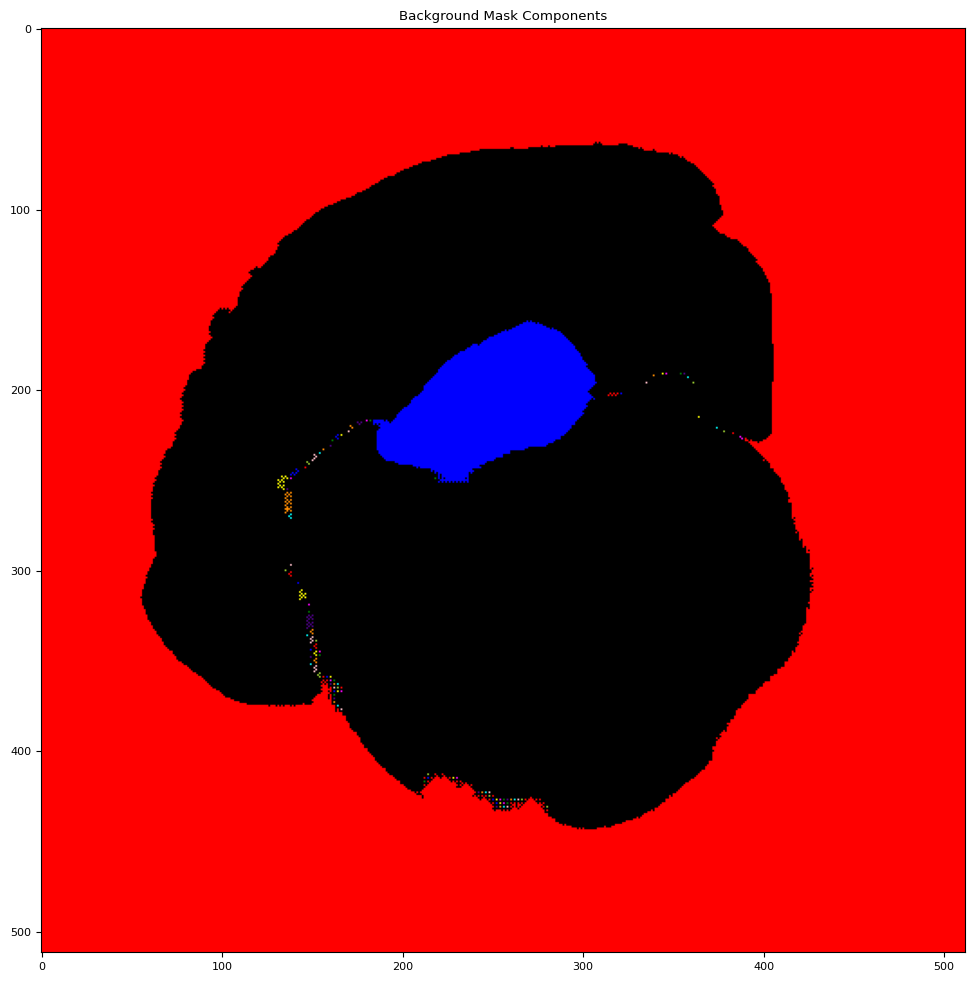

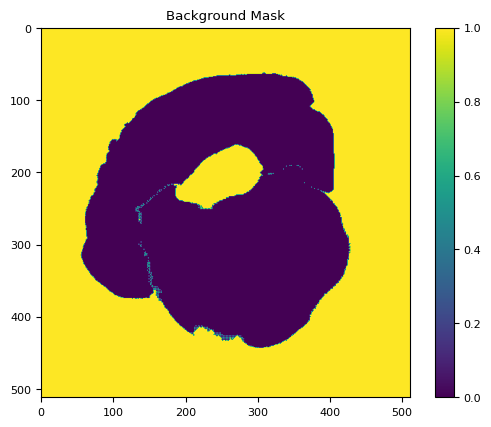

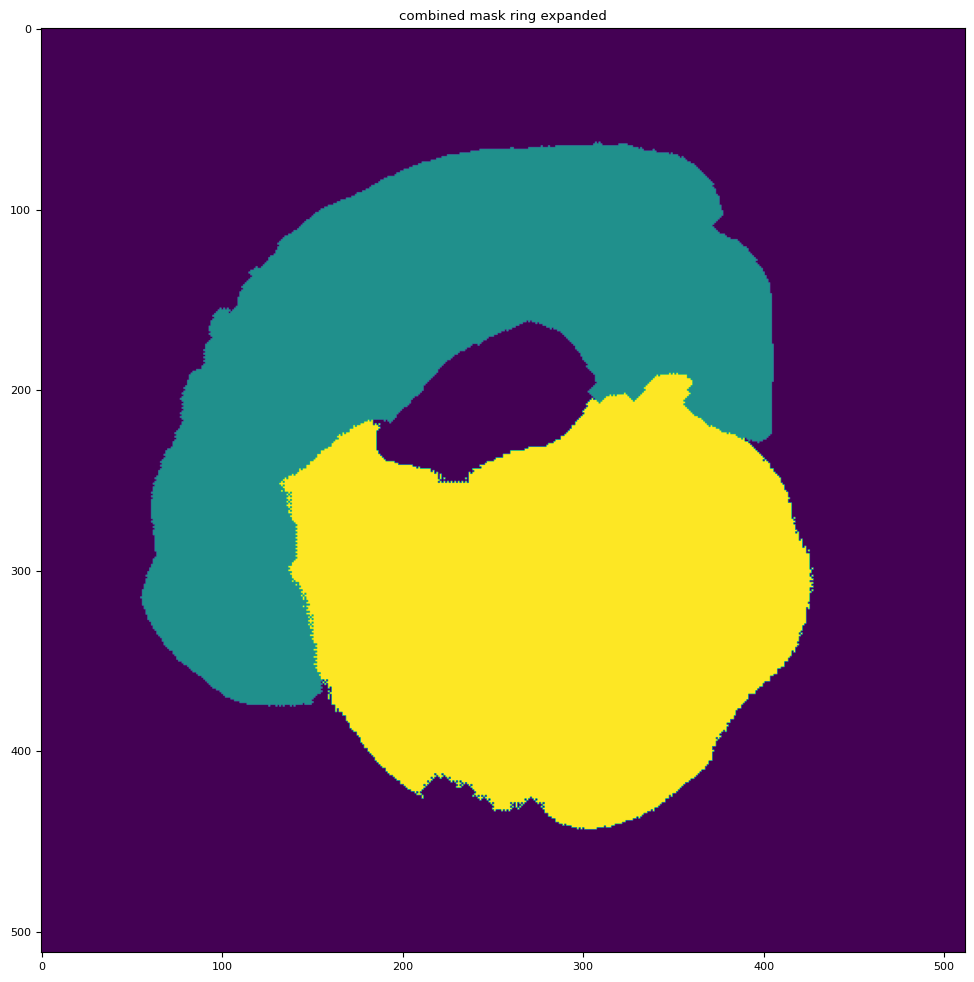

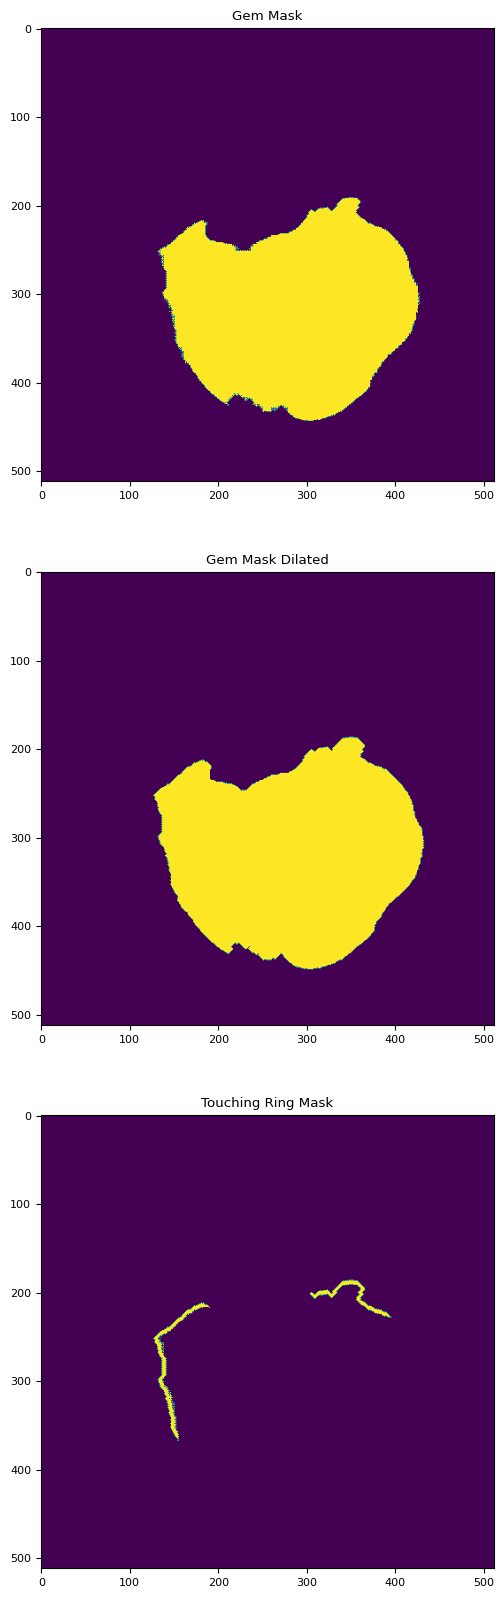

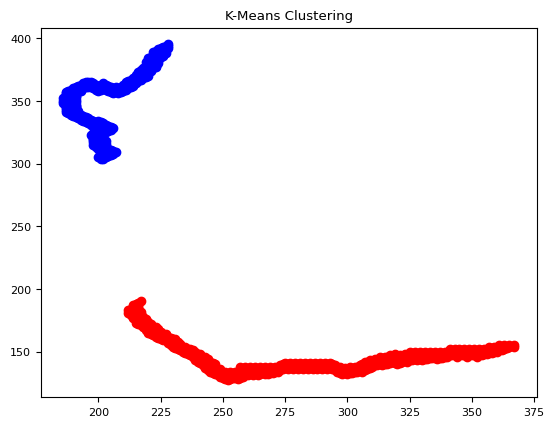

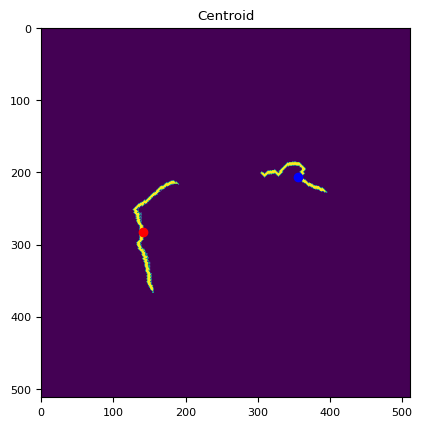

Ring Pixel Image Shape: (512, 512)
Maximum Pixel Value: 0.4920024871826172 Minimum Pixel Value: 0.0


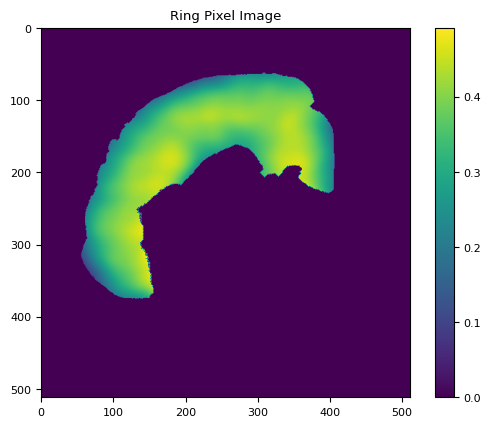

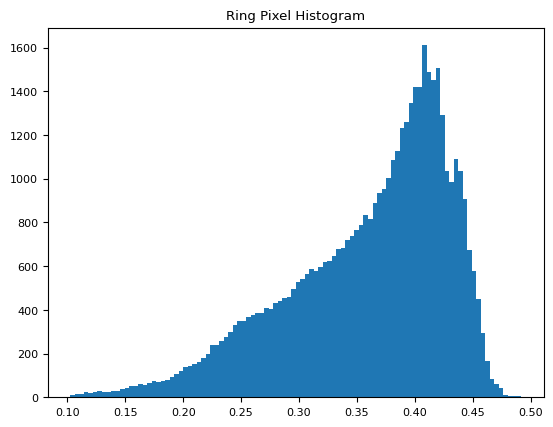

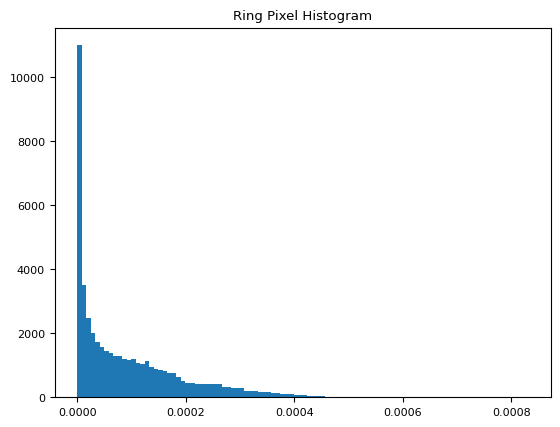

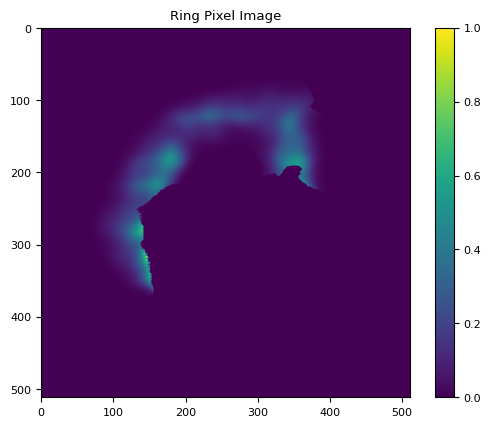

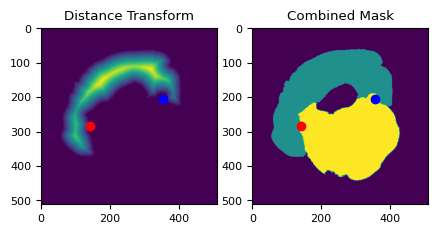

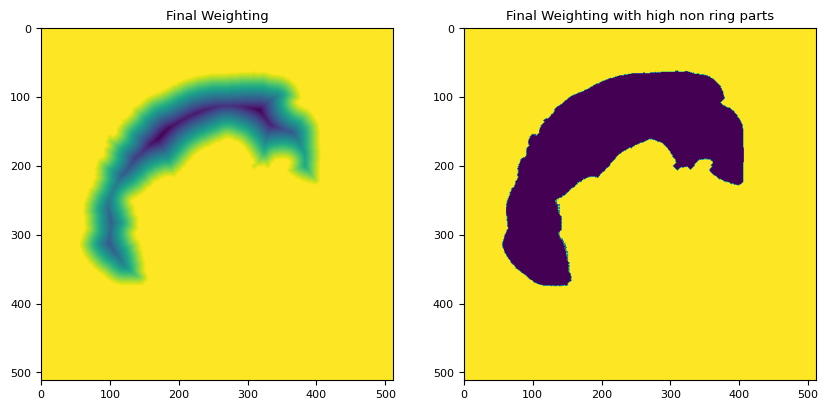

weight: 128.48209793883439


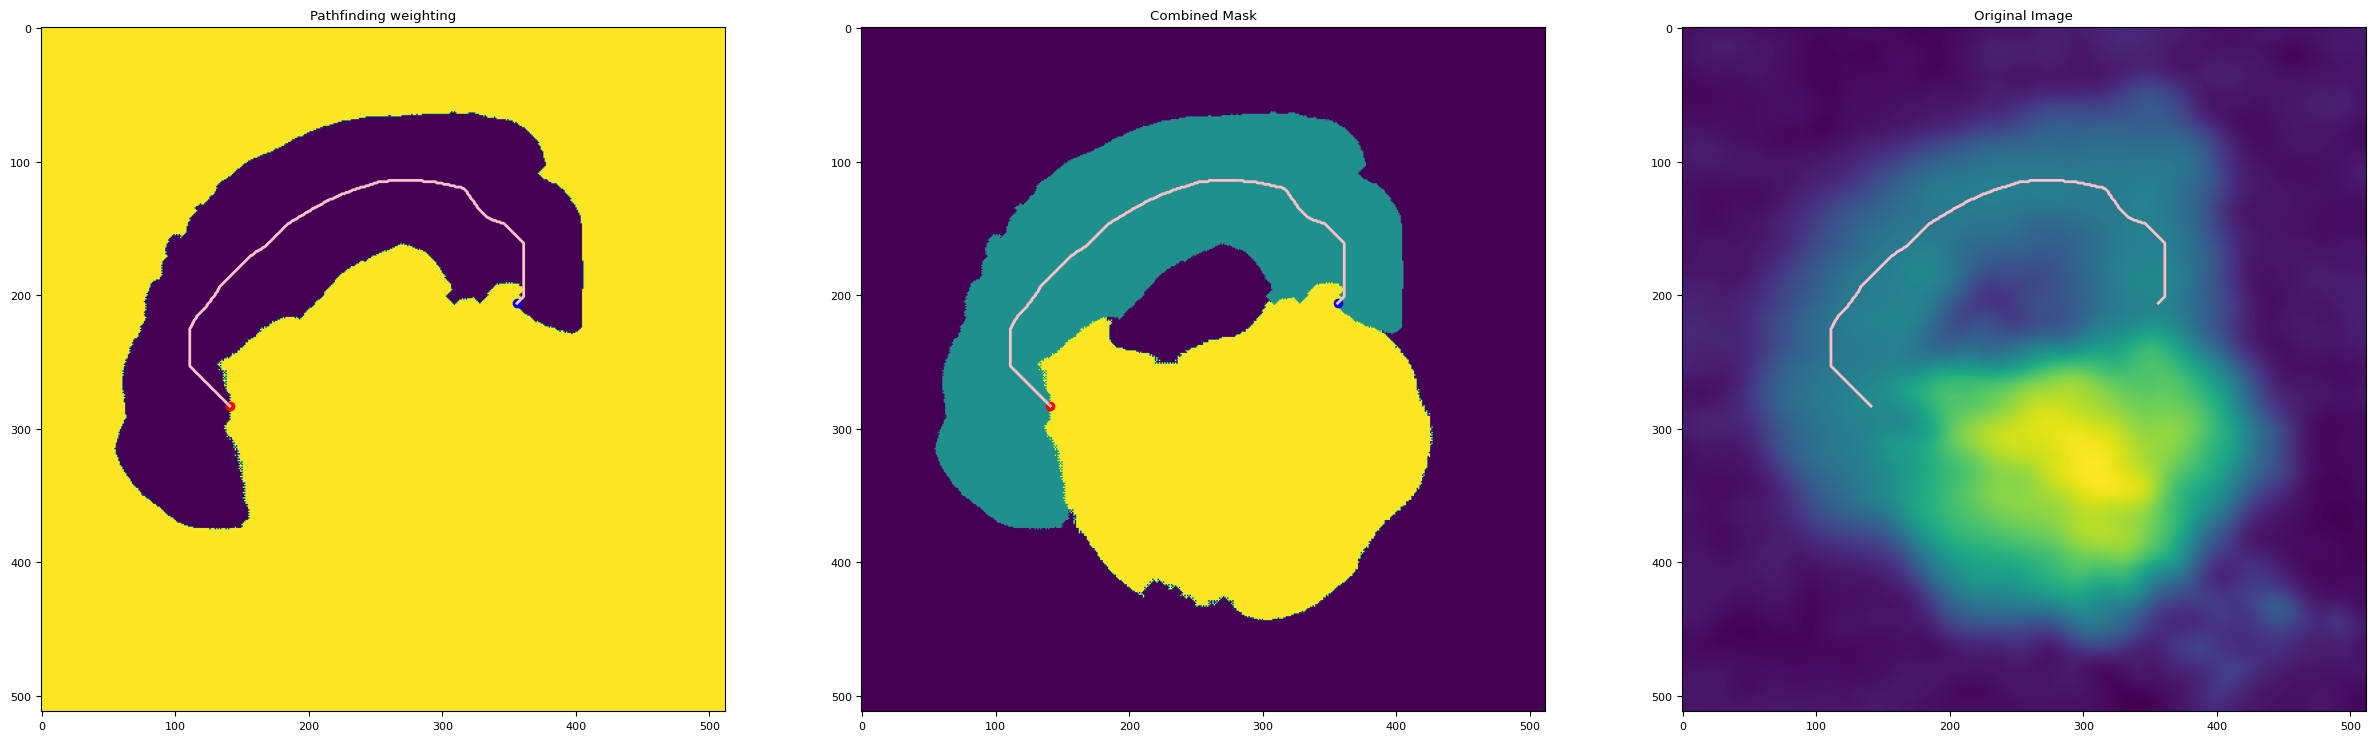

In [105]:
threshold = 0.5


def run_all_steps(image_index: int, threshold: float):
    image_512, predicted_mask, combined_predicted_mask = predict_mask(
        image_index,
        gem_threshold=threshold,
        ring_threshold=threshold,
        background_threshold=threshold,
    )
    combined_predicted_mask = turn_small_gem_regions_into_ring(
        image_512, predicted_mask, combined_predicted_mask
    )
    combined_predicted_mask = remove_small_ring_regions(
        image_512, predicted_mask, combined_predicted_mask
    )
    combined_predicted_mask = ensure_connecting_ring_and_gem(
        image_512, predicted_mask, combined_predicted_mask
    )
    combined_predicted_mask = remove_small_background_regions(
        image_512, predicted_mask, combined_predicted_mask
    )
    near_gem_and_ring = find_connecting_regions(image_512, predicted_mask, combined_predicted_mask)
    centroid_1, centroid_2 = find_centroids_of_connecting_regions(
        image_512, predicted_mask, combined_predicted_mask, near_gem_and_ring
    )
    pathfinding_weighting_visualisation, final_weighting = create_pathdinging_weighting(
        image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2
    )
    path_image, path = find_path(
        image_512, predicted_mask, combined_predicted_mask, centroid_1, centroid_2, final_weighting
    )


# Find the number of images available
num_images = len(list(IMAGE_DIR.glob("*.npy")))
for image_index in range(0, 1):
    run_all_steps(image_index, threshold)